# Notebook 5: Linear & Polynomial Regression + Regularization
Part 5/30 – ML Mastery Series for Python Experts

## Linear Regression – The Foundation (and Its Limits)

Ordinary Least Squares (OLS) is the workhorse of statistical modeling. It minimizes the Mean Squared Error:

$$J(\theta) = \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2 = \frac{1}{n} \|y - X\theta\|^2$$

**Closed-form solution:** $\hat{\theta} = (X^T X)^{-1} X^T y$

**Key assumptions:**
- Linearity: The relationship between features and target is linear
- Independence: Observations are independent (no autocorrelation)
- Homoscedasticity: Constant error variance across predictions
- No perfect multicollinearity among features

**When it fails:** Real-world data rarely respects linearity. Curved relationships, interactions, and complex boundaries require more expressive models—but with great power comes great overfitting.

## Learning Objectives

By the end of this notebook, you will be able to:

- Fit `LinearRegression` and interpret coefficients in the context of prediction
- Extend linear models with `PolynomialFeatures` to capture non-linear patterns
- Recognize overfitting by comparing train vs. test performance metrics
- Apply Ridge (L2), Lasso (L1), and ElasticNet regularization to control model complexity
- Understand how regularization paths affect coefficient shrinkage and sparsity
- Build safe `Pipeline` objects to prevent data leakage between preprocessing and modeling
- Use `learning_curve` to diagnose bias-variance trade-offs visually
- Select optimal hyperparameters using `GridSearchCV` with cross-validation

## 📈 1. Simple Linear Regression Baseline

Let's establish a baseline using the diabetes dataset. We'll use a Pipeline to ensure scaling happens correctly within cross-validation folds.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score

# Configure plotting
%matplotlib inline
sns.set_theme(style="whitegrid")

# Load the diabetes dataset (442 samples, 10 features)
diabetes = load_diabetes()
X, y = diabetes.data, diabetes.target

# Split into train/test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training set: {X_train.shape}, Test set: {X_test.shape}")

Training set: (353, 10), Test set: (89, 10)


In [2]:
# Build a simple pipeline: scale features, then fit linear regression
baseline_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('linreg', LinearRegression())
])

# Fit on training data
baseline_pipe.fit(X_train, y_train)

# Predict on both sets
y_train_pred = baseline_pipe.predict(X_train)
y_test_pred = baseline_pipe.predict(X_test)

# Calculate metrics
train_mse = mean_squared_error(y_train, y_train_pred)
test_mse = mean_squared_error(y_test, y_test_pred)
train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)

print(f"Train MSE: {train_mse:.2f}, R²: {train_r2:.3f}")
print(f"Test MSE:  {test_mse:.2f}, R²:  {test_r2:.3f}")

Train MSE: 2868.55, R²: 0.528
Test MSE:  2900.19, R²:  0.453


## 📈 2. Introducing Polynomial Features

Linear models assume linear relationships. We can break this assumption by adding polynomial features—automatically creating interaction terms and powers of original features.

⚠️ **Critical:** Always place `PolynomialFeatures` BEFORE scaling in the pipeline, since polynomial expansion dramatically changes feature scales.

In [3]:
from sklearn.preprocessing import PolynomialFeatures

# Create pipeline with degree-2 polynomial features
poly2_pipe = Pipeline([
    ('poly', PolynomialFeatures(degree=2, include_bias=False)),
    ('scaler', StandardScaler()),
    ('linreg', LinearRegression())
])

# Fit and evaluate
poly2_pipe.fit(X_train, y_train)
y_train_pred2 = poly2_pipe.predict(X_train)
y_test_pred2 = poly2_pipe.predict(X_test)

print(f"Degree 2 - Train MSE: {mean_squared_error(y_train, y_train_pred2):.2f}")
print(f"Degree 2 - Test MSE:  {mean_squared_error(y_test, y_test_pred2):.2f}")
print(f"Number of features: {poly2_pipe.named_steps['poly'].n_output_features_}")

Degree 2 - Train MSE: 2393.14
Degree 2 - Test MSE:  3096.03
Number of features: 65


In [4]:
# Let's try degree 3 (danger zone without regularization!)
poly3_pipe = Pipeline([
    ('poly', PolynomialFeatures(degree=3, include_bias=False)),
    ('scaler', StandardScaler()),
    ('linreg', LinearRegression())
])

poly3_pipe.fit(X_train, y_train)
y_train_pred3 = poly3_pipe.predict(X_train)
y_test_pred3 = poly3_pipe.predict(X_test)

print(f"Degree 3 - Train MSE: {mean_squared_error(y_train, y_train_pred3):.2f}")
print(f"Degree 3 - Test MSE:  {mean_squared_error(y_test, y_test_pred3):.2f}")
print(f"Number of features: {poly3_pipe.named_steps['poly'].n_output_features_}")

# Notice: Test error got WORSE despite perfect training fit (overfitting!)

Degree 3 - Train MSE: 745.62
Degree 3 - Test MSE:  82446.05
Number of features: 285


## 📉 3. Visualizing Overfitting – Learning Curves

Learning curves show how train and validation scores evolve as we increase training data. High-degree polynomials show a large gap between curves (high variance/overfitting).

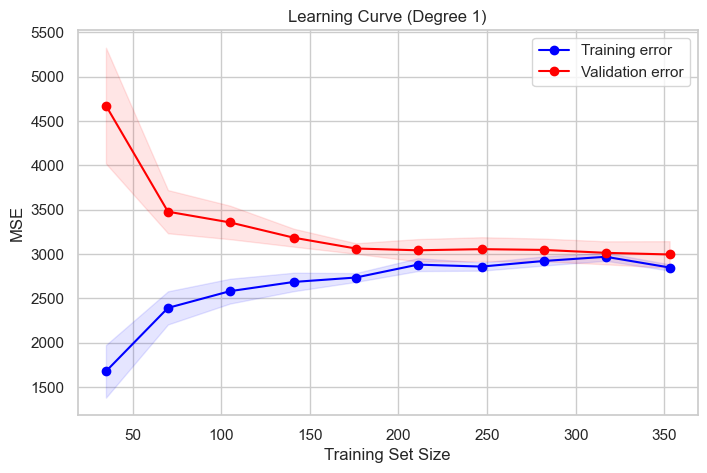

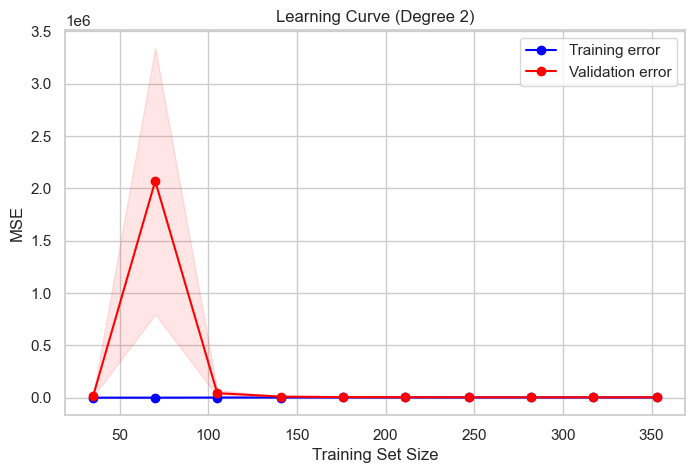

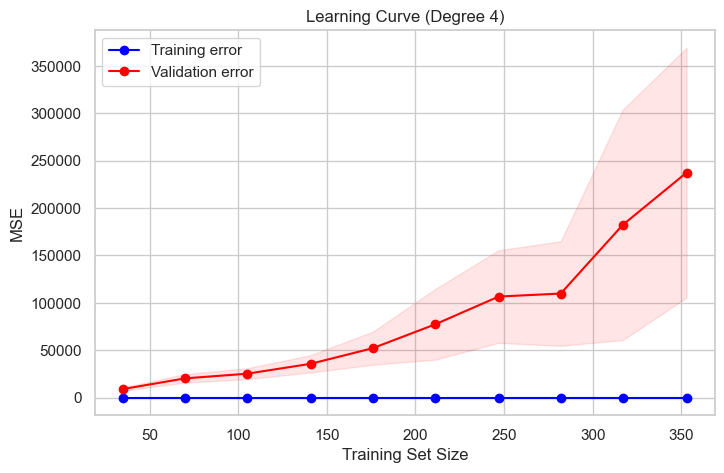

In [5]:
from sklearn.model_selection import learning_curve

def plot_learning_curve(estimator, title, X, y, cv=5):
    """Plot learning curves for a given estimator."""
    train_sizes, train_scores, val_scores = learning_curve(
        estimator, X, y, cv=cv, scoring='neg_mean_squared_error',
        train_sizes=np.linspace(0.1, 1.0, 10), random_state=42
    )
    
    # Convert to positive MSE
    train_scores = -train_scores
    val_scores = -val_scores
    
    plt.figure(figsize=(8, 5))
    plt.plot(train_sizes, train_scores.mean(axis=1), 'o-', color='blue', label='Training error')
    plt.plot(train_sizes, val_scores.mean(axis=1), 'o-', color='red', label='Validation error')
    plt.fill_between(train_sizes, train_scores.mean(axis=1) - train_scores.std(axis=1),
                     train_scores.mean(axis=1) + train_scores.std(axis=1), alpha=0.1, color='blue')
    plt.fill_between(train_sizes, val_scores.mean(axis=1) - val_scores.std(axis=1),
                     val_scores.mean(axis=1) + val_scores.std(axis=1), alpha=0.1, color='red')
    plt.title(title)
    plt.xlabel('Training Set Size')
    plt.ylabel('MSE')
    plt.legend()
    plt.show()

# Compare degrees 1, 2, and 4
for degree in [1, 2, 4]:
    pipe = Pipeline([
        ('poly', PolynomialFeatures(degree=degree, include_bias=False)),
        ('scaler', StandardScaler()),
        ('linreg', LinearRegression())
    ])
    plot_learning_curve(pipe, f'Learning Curve (Degree {degree})', X, y)

## 🛡️ 4. Ridge Regression (L2 Regularization)

Ridge adds an L2 penalty to the loss function:

$$J(\theta) = \text{MSE} + \alpha \sum_{j=1}^{p} \theta_j^2$$

This shrinks coefficients toward zero without forcing them exactly to zero. Higher $\alpha$ = stronger regularization.

In [6]:
from sklearn.linear_model import Ridge

# Test different alpha values for Ridge with degree-2 polynomials
alphas = [0.001, 0.1, 1, 10, 100]
ridge_results = []

for alpha in alphas:
    ridge_pipe = Pipeline([
        ('poly', PolynomialFeatures(degree=2, include_bias=False)),
        ('scaler', StandardScaler()),
        ('ridge', Ridge(alpha=alpha, random_state=42))
    ])
    ridge_pipe.fit(X_train, y_train)
    
    train_mse = mean_squared_error(y_train, ridge_pipe.predict(X_train))
    test_mse = mean_squared_error(y_test, ridge_pipe.predict(X_test))
    ridge_results.append({'alpha': alpha, 'train_mse': train_mse, 'test_mse': test_mse})

ridge_df = pd.DataFrame(ridge_results)
print(ridge_df)

     alpha    train_mse     test_mse
0    0.001  2393.522793  3090.441719
1    0.100  2408.647291  3066.912472
2    1.000  2424.173684  2883.363029
3   10.000  2492.145427  2633.108968
4  100.000  2668.831295  2659.112363


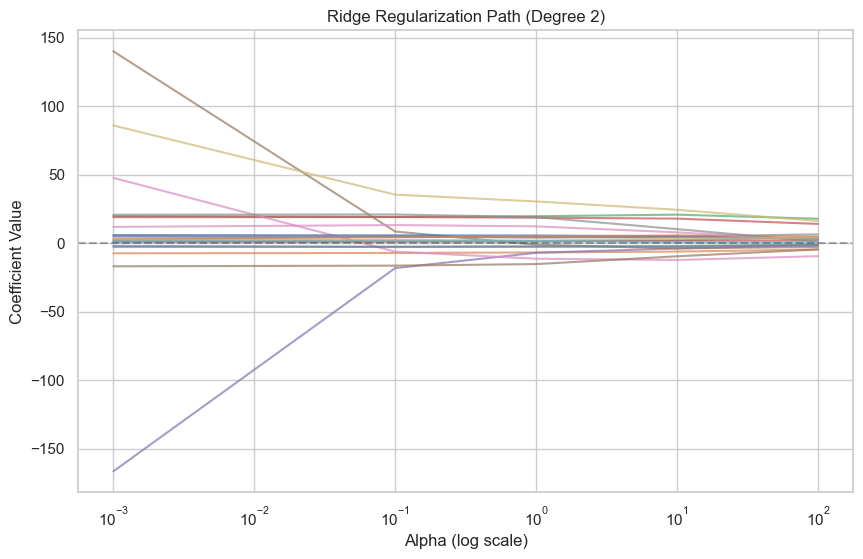

Observation: Coefficients shrink smoothly toward zero as alpha increases, but never reach exactly zero.


In [7]:
# Visualize the regularization path (coefficients vs alpha)
coefs = []
for alpha in alphas:
    ridge = Pipeline([
        ('poly', PolynomialFeatures(degree=2, include_bias=False)),
        ('scaler', StandardScaler()),
        ('ridge', Ridge(alpha=alpha))
    ])
    ridge.fit(X_train, y_train)
    coefs.append(ridge.named_steps['ridge'].coef_)

coefs = np.array(coefs)
plt.figure(figsize=(10, 6))
for i in range(min(20, coefs.shape[1])):  # Plot first 20 coefficients
    plt.plot(alphas, coefs[:, i], alpha=0.7)
plt.xscale('log')
plt.xlabel('Alpha (log scale)')
plt.ylabel('Coefficient Value')
plt.title('Ridge Regularization Path (Degree 2)')
plt.axhline(y=0, color='black', linestyle='--', alpha=0.3)
plt.show()

print("Observation: Coefficients shrink smoothly toward zero as alpha increases, but never reach exactly zero.")

## ✂️ 5. Lasso Regression (L1 Regularization)

Lasso uses an L1 penalty:

$$J(\theta) = \text{MSE} + \alpha \sum_{j=1}^{p} |\theta_j|$$

This can drive coefficients exactly to zero, performing automatic feature selection.

In [8]:
from sklearn.linear_model import Lasso

# Test Lasso with different alphas
lasso_results = []
nonzero_counts = []

for alpha in alphas:
    lasso_pipe = Pipeline([
        ('poly', PolynomialFeatures(degree=2, include_bias=False)),
        ('scaler', StandardScaler()),
        ('lasso', Lasso(alpha=alpha, random_state=42, max_iter=10000))
    ])
    lasso_pipe.fit(X_train, y_train)
    
    train_mse = mean_squared_error(y_train, lasso_pipe.predict(X_train))
    test_mse = mean_squared_error(y_test, lasso_pipe.predict(X_test))
    coefs_count = np.sum(np.abs(lasso_pipe.named_steps['lasso'].coef_) > 1e-5)
    
    lasso_results.append({'alpha': alpha, 'train_mse': train_mse, 'test_mse': test_mse, 'nonzero': coefs_count})

lasso_df = pd.DataFrame(lasso_results)
print(lasso_df)

     alpha    train_mse     test_mse  nonzero
0    0.001  2400.073965  3098.206135       65
1    0.100  2449.896509  2761.385492       54
2    1.000  2630.037680  2563.881379       36
3   10.000  3250.403753  2933.834730        4
4  100.000  6076.398013  5361.533457        0


c:\Users\786\miniconda3\envs\env_dl\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.443e+05, tolerance: 2.145e+02
  model = cd_fast.enet_coordinate_descent(


Ridge non-zero coefficients: 65 / 65
Lasso non-zero coefficients: 36 / 65


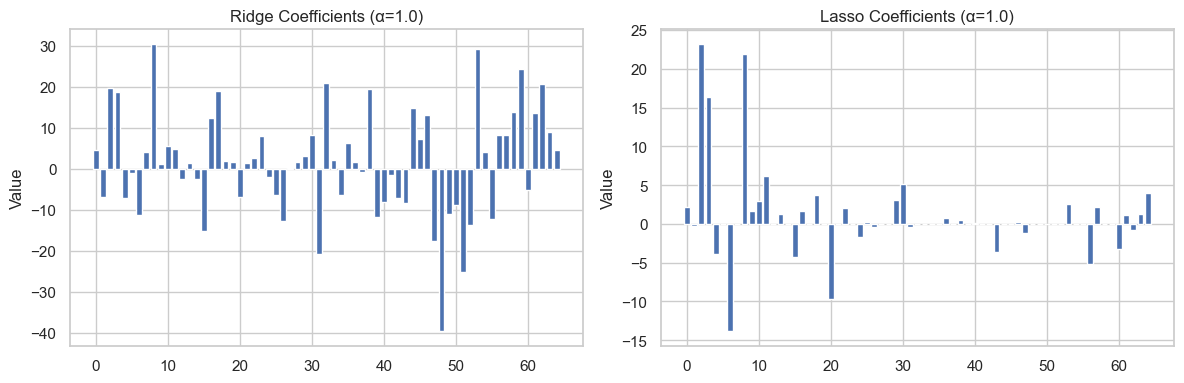

In [9]:
# Compare Ridge vs Lasso coefficient sparsity at alpha=1.0
ridge_comp = Pipeline([
    ('poly', PolynomialFeatures(degree=2, include_bias=False)),
    ('scaler', StandardScaler()),
    ('ridge', Ridge(alpha=1.0))
]).fit(X_train, y_train)

lasso_comp = Pipeline([
    ('poly', PolynomialFeatures(degree=2, include_bias=False)),
    ('scaler', StandardScaler()),
    ('lasso', Lasso(alpha=1.0, max_iter=10000))
]).fit(X_train, y_train)

ridge_coefs = ridge_comp.named_steps['ridge'].coef_
lasso_coefs = lasso_comp.named_steps['lasso'].coef_

print(f"Ridge non-zero coefficients: {np.sum(np.abs(ridge_coefs) > 1e-5)} / {len(ridge_coefs)}")
print(f"Lasso non-zero coefficients: {np.sum(np.abs(lasso_coefs) > 1e-5)} / {len(lasso_coefs)}")

# Visual comparison
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(range(len(ridge_coefs)), ridge_coefs)
axes[0].set_title('Ridge Coefficients (α=1.0)')
axes[0].set_ylabel('Value')
axes[1].bar(range(len(lasso_coefs)), lasso_coefs)
axes[1].set_title('Lasso Coefficients (α=1.0)')
axes[1].set_ylabel('Value')
plt.tight_layout()
plt.show()

## ⚖️ 6. ElasticNet – Combining L1 & L2

ElasticNet combines both penalties:

$$J(\theta) = \text{MSE} + \alpha \cdot \text{l1_ratio} \sum |\theta_j| + \alpha \cdot (1 - \text{l1_ratio}) \sum \theta_j^2$$

`l1_ratio=1` is Lasso, `l1_ratio=0` is Ridge.

In [10]:
from sklearn.linear_model import ElasticNet

# Fixed alpha, varying l1_ratio
l1_ratios = [0.1, 0.5, 0.9]
elastic_results = []

for l1_ratio in l1_ratios:
    elastic_pipe = Pipeline([
        ('poly', PolynomialFeatures(degree=2, include_bias=False)),
        ('scaler', StandardScaler()),
        ('elastic', ElasticNet(alpha=1.0, l1_ratio=l1_ratio, random_state=42, max_iter=10000))
    ])
    elastic_pipe.fit(X_train, y_train)
    
    test_mse = mean_squared_error(y_test, elastic_pipe.predict(X_test))
    nonzero = np.sum(np.abs(elastic_pipe.named_steps['elastic'].coef_) > 1e-5)
    elastic_results.append({'l1_ratio': l1_ratio, 'test_mse': test_mse, 'nonzero_coefs': nonzero})

elastic_df = pd.DataFrame(elastic_results)
print(elastic_df)
print("\nObservation: Higher l1_ratio → more sparsity (Lasso-like), lower → more shrinkage (Ridge-like)")

   l1_ratio     test_mse  nonzero_coefs
0       0.1  2932.008284             60
1       0.5  2772.301179             50
2       0.9  2597.048240             40

Observation: Higher l1_ratio → more sparsity (Lasso-like), lower → more shrinkage (Ridge-like)


## 🎯 7. Putting It Together – Best Regularized Polynomial Model

Now we use `GridSearchCV` to find the optimal combination of polynomial degree and regularization strength. This is where Pipelines really shine—no data leakage, proper cross-validation.

In [11]:
from sklearn.model_selection import GridSearchCV

# Define the full pipeline
full_pipe = Pipeline([
    ('poly', PolynomialFeatures(include_bias=False)),
    ('scaler', StandardScaler()),
    ('model', Ridge())  # placeholder, will be replaced by GridSearch
])

# Define parameter grid
param_grid = [
    {
        'poly__degree': [1, 2, 3],
        'model': [Ridge()],
        'model__alpha': [0.01, 0.1, 1, 10, 100]
    },
    {
        'poly__degree': [1, 2, 3],
        'model': [Lasso(max_iter=10000)],
        'model__alpha': [0.01, 0.1, 1, 10]
    }
]

# Run grid search with 5-fold CV
grid = GridSearchCV(full_pipe, param_grid, cv=5, scoring='neg_mean_squared_error', n_jobs=-1)
grid.fit(X_train, y_train)

print(f"Best parameters: {grid.best_params_}")
print(f"Best CV score (MSE): {-grid.best_score_:.2f}")

Best parameters: {'model': Ridge(), 'model__alpha': 10, 'poly__degree': 1}
Best CV score (MSE): 3128.00


In [12]:
# Final evaluation on hold-out test set
best_model = grid.best_estimator_
y_test_final = best_model.predict(X_test)
final_mse = mean_squared_error(y_test, y_test_final)
final_r2 = r2_score(y_test, y_test_final)

print(f"Final Test MSE: {final_mse:.2f}")
print(f"Final Test R²:  {final_r2:.3f}")

# Show which model type won
best_model_type = grid.best_params_['model'].__class__.__name__
print(f"\nWinning model: {best_model_type} with degree={grid.best_params_['poly__degree']}")

Final Test MSE: 2875.78
Final Test R²:  0.457

Winning model: Ridge with degree=1


## ⚠️ Common Pitfalls & Pro Tips

- **🚨 Scaling before PolynomialFeatures:** Always expand polynomials first, then scale. Polynomial features have vastly different scales (x vs x² vs x³).
- **🚨 Too high degree without regularization:** Degree 5+ without Ridge/Lasso often creates numerical instability and severe overfitting.
- **🚨 Alpha=0 confusion:** `Ridge(alpha=0)` or `Lasso(alpha=0)` should equal LinearRegression, but numerical solvers may behave differently. Use `LinearRegression` explicitly for baseline.
- **🚨 Lasso instability:** With highly correlated features, Lasso tends to pick one arbitrarily and zero out others. Use ElasticNet or group Lasso for correlated groups.
- **🚨 Forgetting max_iter:** Lasso and ElasticNet need `max_iter=10000` or higher for convergence with polynomial features.
- **🚨 Interpreting coefficients:** After scaling, coefficients represent "standard deviation change in target per 1 SD change in feature," not original units.
- **🚨 Validation leakage:** Never fit `PolynomialFeatures` or `StandardScaler` on the full dataset before splitting. Always use Pipeline.
- **🎯 Ridge for prediction, Lasso for interpretation:** Ridge generally gives better prediction accuracy; Lasso helps identify important features.
- **🎯 Log scale for alpha:** When searching alpha, use logarithmic spacing (0.001, 0.01, 0.1, 1, 10, 100) rather than linear.
- **🎯 Cross-validation is mandatory:** Test set performance varies. Always use CV to select hyperparameters, not single train/test split.

## 📝 Exercises

**Easy:**
1. Try `degree=3` on the diabetes dataset with `Ridge(alpha=10)`. Compare the test MSE to the baseline linear model (degree=1). How much improvement does polynomial expansion + regularization provide?

**Medium:**
2. Plot the full regularization path for Lasso on the diabetes dataset using `lasso_path` from sklearn or by manually fitting across many alphas. Color-code features and identify which polynomial terms survive longest as alpha increases.

3. Use `make_regression(n_features=20, n_informative=5, noise=10)` to generate synthetic data. Show that Lasso correctly zeros out the 15 irrelevant features while Ridge keeps small but non-zero weights for all.

**Hard:**
4. Implement a function `find_best_poly_reg(X, y, degrees=[1,2,3], alphas=[0.1,1,10], models=['ridge','lasso'])` that:
   - Uses 5-fold CV to evaluate all combinations
   - Returns the best test MSE, best parameters, and fitted pipeline
   - Includes proper docstring and type hints

**Bonus:**
5. Compare ElasticNet performance on `California Housing` vs `Diabetes` datasets. Which dataset benefits more from the L1/L2 hybrid? Investigate whether the difference relates to feature correlation structures.

<details>
<summary><b>Exercise Solutions (Click to Expand)</b></summary>

### Exercise 1 Solution

```python
pipe_deg3_ridge = Pipeline([
    ('poly', PolynomialFeatures(degree=3, include_bias=False)),
    ('scaler', StandardScaler()),
    ('ridge', Ridge(alpha=10))
]).fit(X_train, y_train)

mse_deg3 = mean_squared_error(y_test, pipe_deg3_ridge.predict(X_test))
print(f"Degree 3 + Ridge MSE: {mse_deg3:.2f}")
print(f"Baseline (Degree 1) MSE: {test_mse:.2f}")
print(f"Improvement: {((test_mse - mse_deg3)/test_mse)*100:.1f}%")
```

### Exercise 2 Solution

```python
from sklearn.linear_model import lasso_path

# Generate polynomial features first (outside pipeline for lasso_path)
poly = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly.fit_transform(StandardScaler().fit_transform(X))
alphas_lasso, coefs_lasso, _ = lasso_path(X_poly, y, alphas=None, max_iter=10000)

plt.figure(figsize=(10, 6))
for i in range(coefs_lasso.shape[0]):
    plt.plot(alphas_lasso, coefs_lasso[i, :], alpha=0.6)
plt.xscale('log')
plt.xlabel('Alpha')
plt.ylabel('Coefficients')
plt.title('Lasso Path for Polynomial Features')
plt.show()
```

### Exercise 3 Solution

```python
from sklearn.datasets import make_regression
X_syn, y_syn = make_regression(n_samples=200, n_features=20, n_informative=5, noise=10, random_state=42)
X_syn_train, X_syn_test, y_syn_train, y_syn_test = train_test_split(X_syn, y_syn, test_size=0.2)

lasso_syn = Lasso(alpha=0.5).fit(X_syn_train, y_syn_train)
ridge_syn = Ridge(alpha=0.5).fit(X_syn_train, y_syn_train)

print("Lasso zeros:", np.sum(np.abs(lasso_syn.coef_) < 1e-5))
print("Ridge small weights (<0.1):", np.sum(np.abs(ridge_syn.coef_) < 0.1))
```

### Exercise 4 Solution

```python
from typing import Dict, Any, List
from sklearn.model_selection import cross_val_score

def find_best_poly_reg(X, y, degrees=[1,2,3], alphas=[0.1,1,10], 
                       models=['ridge','lasso'], cv=5) -> Dict[str, Any]:
    """
    Find optimal polynomial degree and regularization via cross-validation.
    
    Returns dict with 'best_mse', 'best_params', 'best_pipeline'
    """
    best_mse = float('inf')
    best_result = None
    
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    
    for degree in degrees:
        for model_type in models:
            for alpha in alphas:
                if model_type == 'ridge':
                    model = Ridge(alpha=alpha, random_state=42)
                else:
                    model = Lasso(alpha=alpha, random_state=42, max_iter=10000)
                
                pipe = Pipeline([
                    ('poly', PolynomialFeatures(degree=degree, include_bias=False)),
                    ('scaler', StandardScaler()),
                    ('model', model)
                ])
                
                scores = cross_val_score(pipe, X_train, y_train, 
                                       cv=cv, scoring='neg_mean_squared_error')
                mse = -scores.mean()
                
                if mse < best_mse:
                    best_mse = mse
                    pipe.fit(X_train, y_train)
                    test_mse = mean_squared_error(y_test, pipe.predict(X_test))
                    best_result = {
                        'cv_mse': mse,
                        'test_mse': test_mse,
                        'best_params': {'degree': degree, 'model': model_type, 'alpha': alpha},
                        'best_pipeline': pipe
                    }
    return best_result
```

</details>

## 🎓 Summary – What You Learned Today

- **Linear regression** provides a fast, interpretable baseline but assumes linearity that rarely holds in complex data
- **Polynomial features** extend linear models to capture non-linear relationships, but exponentially increase dimensionality and overfitting risk
- **The bias-variance trade-off** is visible in learning curves: high-degree polynomials achieve low training error but fail to generalize
- **Ridge regression (L2)** shrinks coefficients proportionally, handling multicollinearity and stabilizing high-dimensional models without feature selection
- **Lasso regression (L1)** drives coefficients to exactly zero, performing embedded feature selection and creating sparse, interpretable models
- **ElasticNet** balances the benefits of both L1 and L2, particularly useful when features are correlated but you still want some sparsity
- **Pipelines are non-negotiable** for polynomial regression to prevent data leakage and ensure scaling happens correctly within CV folds
- **Cross-validation + grid search** is the robust way to select both polynomial degree and regularization strength


**Auther**: Tassawar Abbas  
**Email**: abbas829@gmail.com